# StockBot: Vanilla LSTM for Stock Price Forecasting
Implements the stacked LSTM from *StockBot 2.0* (Mohanty, 2026).  
Trains a sliding-window model (60-day input → 1-day-ahead output) with Adam, MSE loss, and early stopping. At inference, the model receives the preceding 60 actual days and predicts the next day — no autoregressive feedback.

In [127]:
%pip install -q yfinance torch numpy scikit-learn matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


## 0. Dataset Setup
Downloads the CSV from GitHub if not available locally (e.g. on Colab).

In [128]:
import os, urllib.request

CSV_NAME   = 'aapl_daily_sentiment_2021_2025.csv'
RAW_URL    = ('https://raw.githubusercontent.com/franciscomartinez45/'
              'Stock-Forecasting-LSTM/main/data/processed/' + CSV_NAME)
LOCAL_PATHS = [f'../data/processed/{CSV_NAME}', CSV_NAME]

if not any(os.path.exists(p) for p in LOCAL_PATHS):
    print('Downloading dataset from GitHub...')
    urllib.request.urlretrieve(RAW_URL, CSV_NAME)
    print('Done.')
else:
    print('Dataset found locally.')

Dataset found locally.


## 1. Imports & Config

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader

# ── Hyperparameters (Table 1 from paper) ──────────────────────────────────
TICKER           = 'BRK-A'           # swap to any yfinance-supported ticker
START_DATE       = '2021-05-01'
END_DATE         = '2025-12-31'
PAST_HISTORY     = 60               # days of history per input window
FORECAST_HORIZON = 10               # days ahead to predict (1 or 10)
HIDDEN_DIM       = 64
NUM_LAYERS       = 1
DROPOUT          = 0.1
BATCH_SIZE       = 64
LR               = 1e-3
EPOCHS           = 100              # paper uses 500; 100 suffices with early stopping
PATIENCE         = 15
TRAIN_RATIO      = 0.8

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

Device: mps


## 2. Data
Adjusted close prices, z-score normalised using **training-set statistics only** to prevent leakage.

In [130]:
LOCAL_CSV = next(
    (p for p in ['../data/processed/aapl_daily_sentiment_2021_2025.csv',
                 'aapl_daily_sentiment_2021_2025.csv'] if os.path.exists(p)),
    None
)

def load_prices():
    if LOCAL_CSV and TICKER == 'AAPL':
        import pandas as pd
        df = pd.read_csv(LOCAL_CSV, parse_dates=['date'])
        return df['close'].values.astype(np.float32), df['date'].tolist()
    import yfinance as yf
    df = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
    return df['Close'].values.flatten().astype(np.float32), df.index.tolist()

prices_raw, dates = load_prices()
n          = len(prices_raw)
train_size = int(n * TRAIN_RATIO)

scaler    = StandardScaler()
prices_sc = np.concatenate([
    scaler.fit_transform(prices_raw[:train_size].reshape(-1, 1)).flatten(),
    scaler.transform(prices_raw[train_size:].reshape(-1, 1)).flatten(),
])

print(f'Total: {n} days | Train: {train_size} | Test: {n - train_size}')

Total: 1172 days | Train: 937 | Test: 235


In [131]:
class StockDataset(Dataset):
    def __init__(self, prices):
        self.x = torch.tensor(prices, dtype=torch.float32).unsqueeze(-1)  # (T, 1)

    def __len__(self):
        return len(self.x) - PAST_HISTORY

    def __getitem__(self, idx):
        return self.x[idx : idx + PAST_HISTORY], self.x[idx + PAST_HISTORY, 0]

val_cut  = int(train_size * 0.9)
train_ds = StockDataset(prices_sc[:val_cut])
val_ds   = StockDataset(prices_sc[val_cut - PAST_HISTORY : train_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
print(f'Train: {len(train_ds)} samples | Val: {len(val_ds)} samples')

Train: 783 samples | Val: 94 samples


## 3. Model
Stacked LSTM (Equations 1–6 from paper). The final hidden state is projected to a scalar price prediction.

In [132]:
class StackedLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = 1,
            hidden_size = HIDDEN_DIM,
            num_layers  = NUM_LAYERS,
            batch_first = True,
            dropout     = DROPOUT if NUM_LAYERS > 1 else 0.0,
        )
        self.fc = nn.Linear(HIDDEN_DIM, 1)

    def forward(self, x):          # x: (batch, seq, 1)
        out, _ = self.lstm(x)      # (batch, seq, hidden)
        return self.fc(out[:, -1, :]).squeeze(-1)  # (batch,)

## 4. Training
Adam + MSE loss with early stopping on validation loss.

Epoch  10 | Train 0.0170 | Val 0.0220
Epoch  20 | Train 0.0143 | Val 0.0193
Epoch  30 | Train 0.0120 | Val 0.0152
Epoch  40 | Train 0.0105 | Val 0.0128
Epoch  50 | Train 0.0094 | Val 0.0108
Epoch  60 | Train 0.0089 | Val 0.0100
Epoch  70 | Train 0.0090 | Val 0.0095
Epoch  80 | Train 0.0081 | Val 0.0094
Epoch  90 | Train 0.0074 | Val 0.0089
Epoch 100 | Train 0.0071 | Val 0.0114


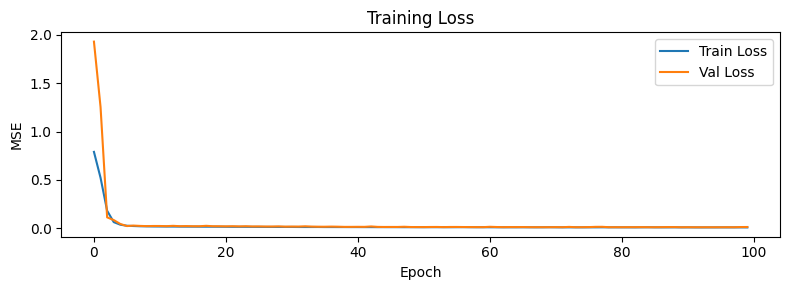

In [133]:
model     = StackedLSTM().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

best_val, patience_count = float('inf'), 0
tr_losses, vl_losses = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    tr = 0.0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        tr += loss.item()

    model.eval()
    vl = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            vl += criterion(model(x.to(DEVICE)), y.to(DEVICE)).item()

    tr_losses.append(tr / len(train_loader))
    vl_losses.append(vl / max(len(val_loader), 1))

    if vl_losses[-1] < best_val:
        best_val, patience_count = vl_losses[-1], 0
        # torch.save(model.state_dict(), 'best_lstm.pt')
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'Early stop at epoch {epoch}')
            break

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | Train {tr_losses[-1]:.4f} | Val {vl_losses[-1]:.4f}')

# model.load_state_dict(torch.load('best_lstm.pt', map_location=DEVICE, weights_only=True))

os.makedirs('plots', exist_ok=True)

plt.figure(figsize=(8, 3))
plt.plot(tr_losses, label='Train Loss')
plt.plot(vl_losses, label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend()
plt.title('Training Loss'); plt.tight_layout()
plt.savefig('plots/training_loss.png', dpi=150)
plt.show()

## 5. Autoregressive Multi-Step Forecasting
The model predicts one day at a time. At inference, predictions are fed back into the window for FORECAST_HORIZON steps, then the window resets to real prices for the next chunk.

In [134]:
@torch.no_grad()
def sliding_window_forecast(n_steps):
    model.eval()
    all_preds = []
    i = 0
    while i + FORECAST_HORIZON <= n_steps:
        window = list(prices_sc[train_size - PAST_HISTORY + i : train_size + i])
        for _ in range(FORECAST_HORIZON):
            x = torch.tensor(window[-PAST_HISTORY:], dtype=torch.float32).view(1, PAST_HISTORY, 1).to(DEVICE)
            p = model(x).item()
            all_preds.append(p)
            window.append(p)
        i += FORECAST_HORIZON
    return np.array(all_preds)

RMSE: $33.26


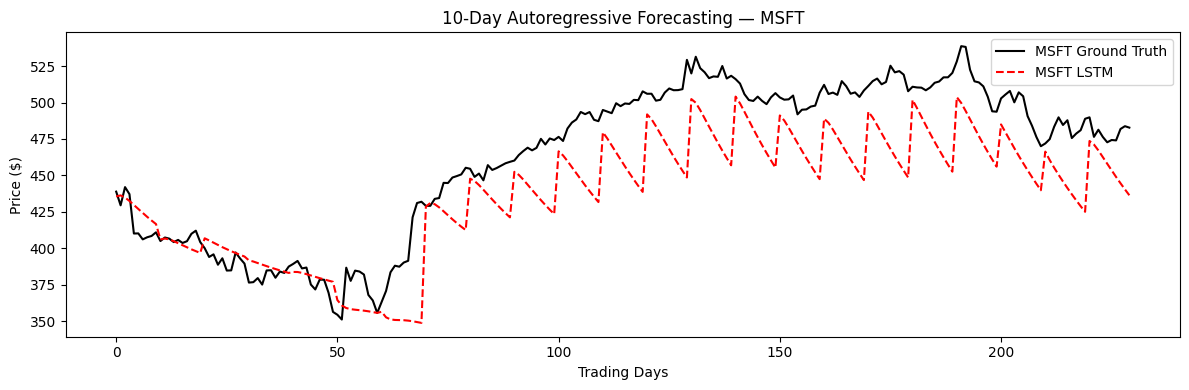

In [135]:
n_test     = n - train_size
preds_sc   = sliding_window_forecast(n_test)
n_preds    = len(preds_sc)          # floor(n_test / FORECAST_HORIZON) * FORECAST_HORIZON
gt_sc      = prices_sc[train_size : train_size + n_preds]
test_dates = dates[train_size : train_size + n_preds]

inv    = lambda x: scaler.inverse_transform(x.reshape(-1, 1)).flatten()
actual = inv(gt_sc)
preds  = inv(preds_sc)

rmse = np.sqrt(np.mean((preds - actual) ** 2))
print(f'RMSE: ${rmse:.2f}')

plt.figure(figsize=(12, 4))
plt.plot(actual, color='black', label=f'{TICKER} Ground Truth', linewidth=1.5)
plt.plot(preds,  color='red',   label=f'{TICKER} LSTM',         linestyle='--')
plt.title(f'{FORECAST_HORIZON}-Day Autoregressive Forecasting — {TICKER}')
plt.xlabel('Trading Days'); plt.ylabel('Price ($)'); plt.legend()
plt.tight_layout()
plt.savefig(f'plots/{TICKER}_forecast.png', dpi=150)
plt.show()

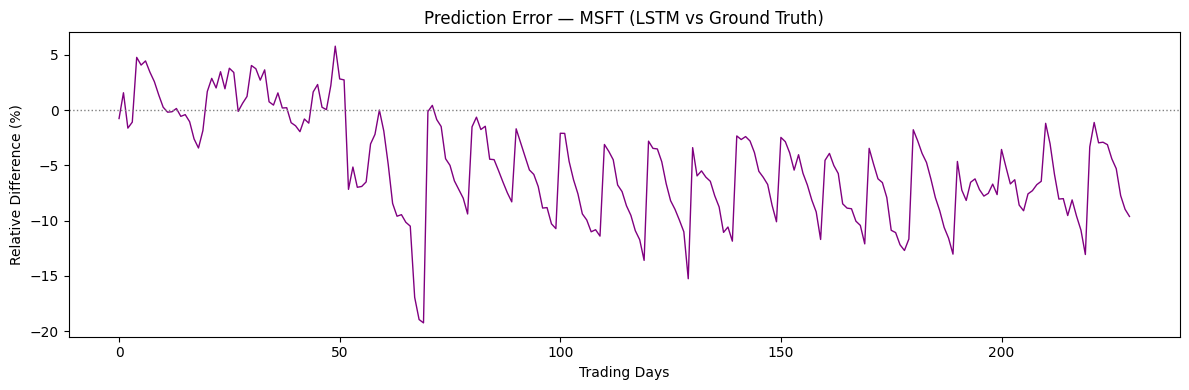

Mean error:  -5.03%
Max error:   5.80%
Min error:   -19.24%


In [136]:
pct_diff = (preds - actual) / actual * 100

plt.figure(figsize=(12, 4))
plt.plot(pct_diff, color='purple', linewidth=1)
plt.axhline(0, color='gray', linestyle=':', linewidth=1)
plt.title(f'Prediction Error — {TICKER} (LSTM vs Ground Truth)')
plt.xlabel('Trading Days'); plt.ylabel('Relative Difference (%)')
plt.tight_layout()
plt.savefig(f'plots/{TICKER}_prediction_error.png', dpi=150)
plt.show()

print(f'Mean error:  {pct_diff.mean():.2f}%')
print(f'Max error:   {pct_diff.max():.2f}%')
print(f'Min error:   {pct_diff.min():.2f}%')

## 6. StockBot Trading Strategy
Uses Algorithm 1 from the paper: δᵢ = sign(cᵢ₊₁ − cᵢ), Δᵢ = δᵢ₊₁ − δᵢ.  
Buy when Δᵢ = +2 (local minimum in predicted prices — prices were falling, now rising), sell when Δᵢ = −2 (local maximum — prices were rising, now falling).

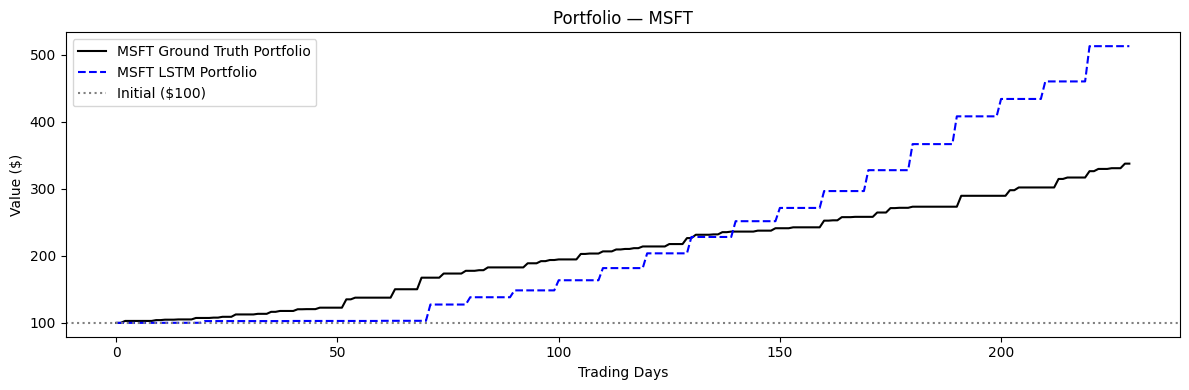

LSTM portfolio final value:         $513.06
Ground truth portfolio final value: $337.71


In [137]:
def stockbot_portfolio(prices, capital=100.0):
    delta = np.sign(np.diff(prices)).astype(int)  # direction of change
    Delta = np.diff(delta)                         # curvature
    held, buy_price, cur = False, 0.0, capital
    portfolio = [cur]
    for i, d in enumerate(Delta):
        signal_price = prices[i + 1]
        if d == 2 and not held:       # local min → buy
            held, buy_price = True, signal_price
        elif d == -2 and held:        # local max → sell
            held = False
            cur *= signal_price / buy_price
        portfolio.append(cur)
    portfolio.append(cur)             # final day
    return np.array(portfolio)

lstm_port = stockbot_portfolio(preds)
gt_port   = stockbot_portfolio(actual)

plt.figure(figsize=(12, 4))
plt.plot(gt_port,   color='black', label=f'{TICKER} Ground Truth Portfolio', linewidth=1.5)
plt.plot(lstm_port, color='blue',  label=f'{TICKER} LSTM Portfolio',         linestyle='--')
plt.axhline(100, color='gray', linestyle=':', label='Initial ($100)')
plt.ticklabel_format(useOffset=False, style='plain')
plt.title(f'Portfolio — {TICKER}')
plt.xlabel('Trading Days'); plt.ylabel('Value ($)'); plt.legend()
plt.tight_layout()
plt.savefig(f'plots/{TICKER}_portfolio.png', dpi=150)
plt.show()

print(f'LSTM portfolio final value:         ${lstm_port[-1]:.2f}')
print(f'Ground truth portfolio final value: ${gt_port[-1]:.2f}')